In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import seaborn as sns
import os
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot
from scipy.stats import boxcox 
from statsmodels.tsa.seasonal import STL
from utils import load_data, check_stationarity
from plots import *

In [2]:
data = load_data()

/Users/andresilva/Desktop/Séries Temporais/TSF-PROJ/utils.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['log_diff'] = np.log(selected_data['tdiff'])
/Users/andresilva/Desktop/Séries Temporais/TSF-PROJ/utils.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['lagged_prec'] = selected_data['prec'].shift(1)
/Users/andresilva/Desktop/Séries Temporais/TSF-PROJ/utils.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

In [3]:
data["t_seasdiff"]= data["tdiff"].diff(12)
data_sd = data.dropna(subset=["t_seasdiff"])

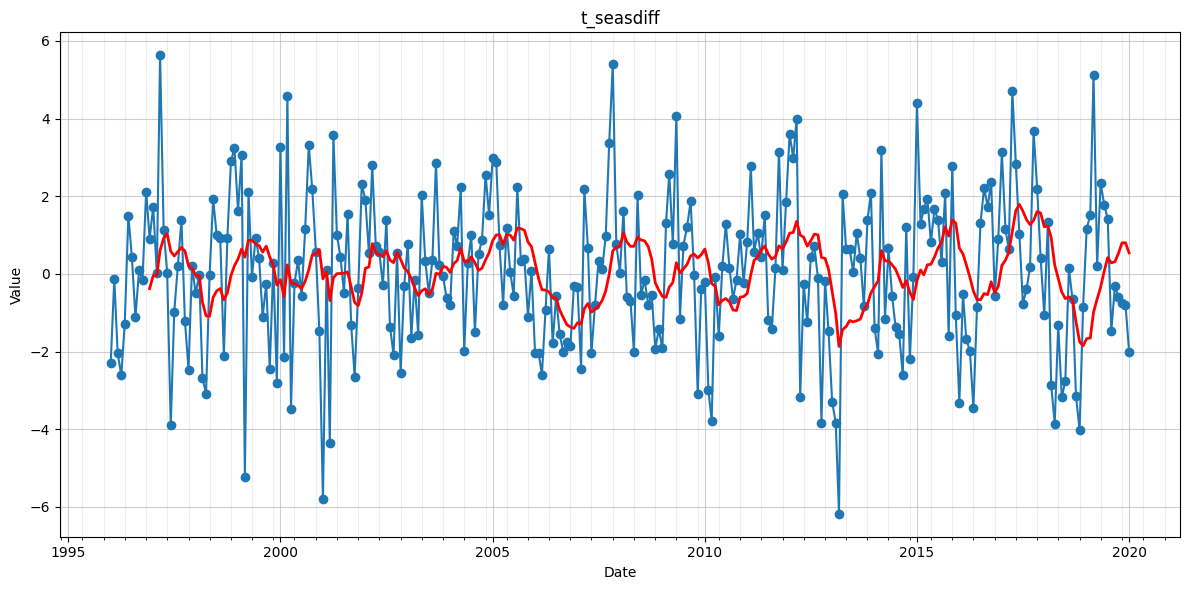

In [4]:
plot_time_series(data_sd, 'date', 't_seasdiff', ma_window=12)

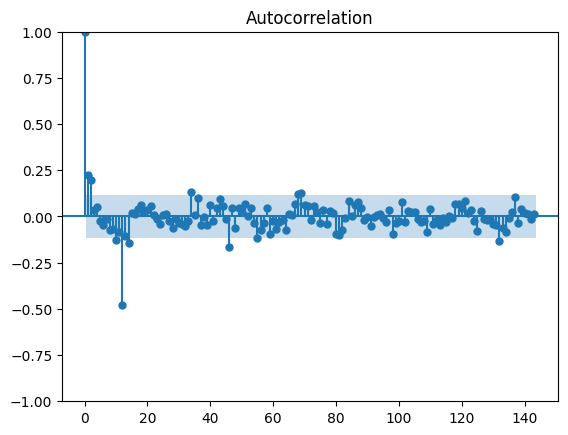

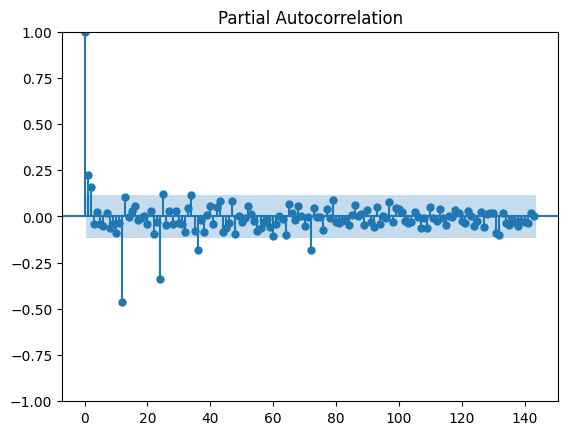

In [8]:
plot_acfs(data_sd, 't_seasdiff', lags=143)

In [9]:
from statsmodels.tsa.stattools import acf, pacf
y = data_sd["t_seasdiff"]

acf_vals = acf(y, nlags=100, fft=True)
pacf_vals = pacf(y, nlags=100, method="ywm")

crit = 1.96 / np.sqrt(len(data_sd))

acf_values_above_crit = [i for i in range(len(acf_vals)) if abs(acf_vals[i]) > crit]
pacf_values_above_crit = [i for i in range(len(pacf_vals)) if abs(pacf_vals[i]) > crit]

print("ACF values above crit:", acf_values_above_crit)
print("PACF values above crit:", pacf_values_above_crit)


ACF values above crit: [0, 1, 2, 10, 12, 14, 34, 46, 55, 68, 69]
PACF values above crit: [0, 1, 2, 12, 24, 25, 34, 36, 72]
